Import some libraries..

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [76]:
df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Data cleaning Process...

In [77]:
df_final = df[["survived","pclass","sex","age","sibsp","parch","fare","embarked","adult_male","deck","alone"]].copy()

In [78]:
# Drop null and duplicates value
df_final.dropna(inplace=True)
df_final.drop_duplicates(inplace=True)

In [79]:
# sum of null values in each column
df_final.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
adult_male,0
deck,0


In [80]:
# sum of duplicates values in each column
df_final.duplicated().sum()

np.int64(0)

In [81]:
# Check size of data
df_final.shape

(181, 11)

Exploratory Data Analysis (EDA)

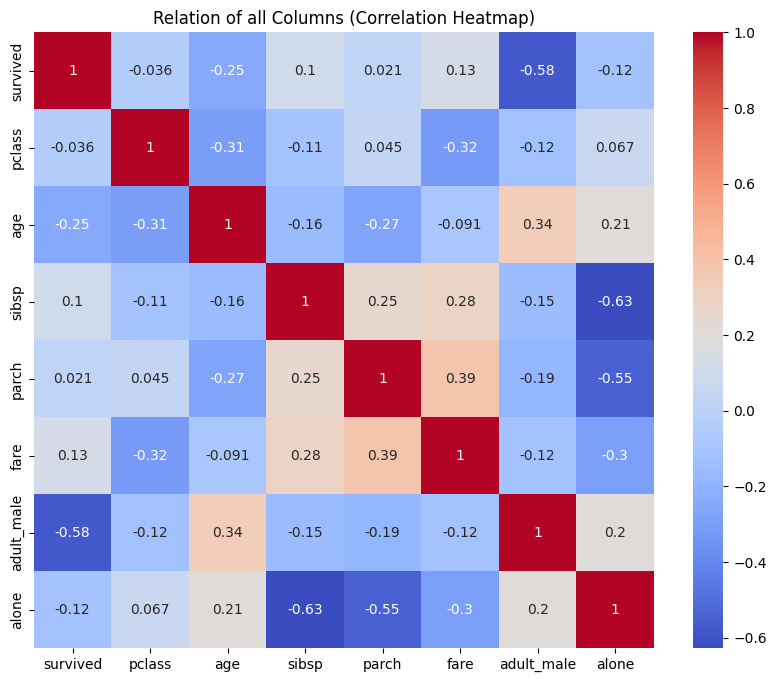

In [82]:
# check relation of all numeric cloumns
plt.figure(figsize=(10, 8))

sns.heatmap(df_final.corr(numeric_only = True), annot=True, cmap="coolwarm")
plt.title("Relation of all Columns (Correlation Heatmap)")
plt.show()

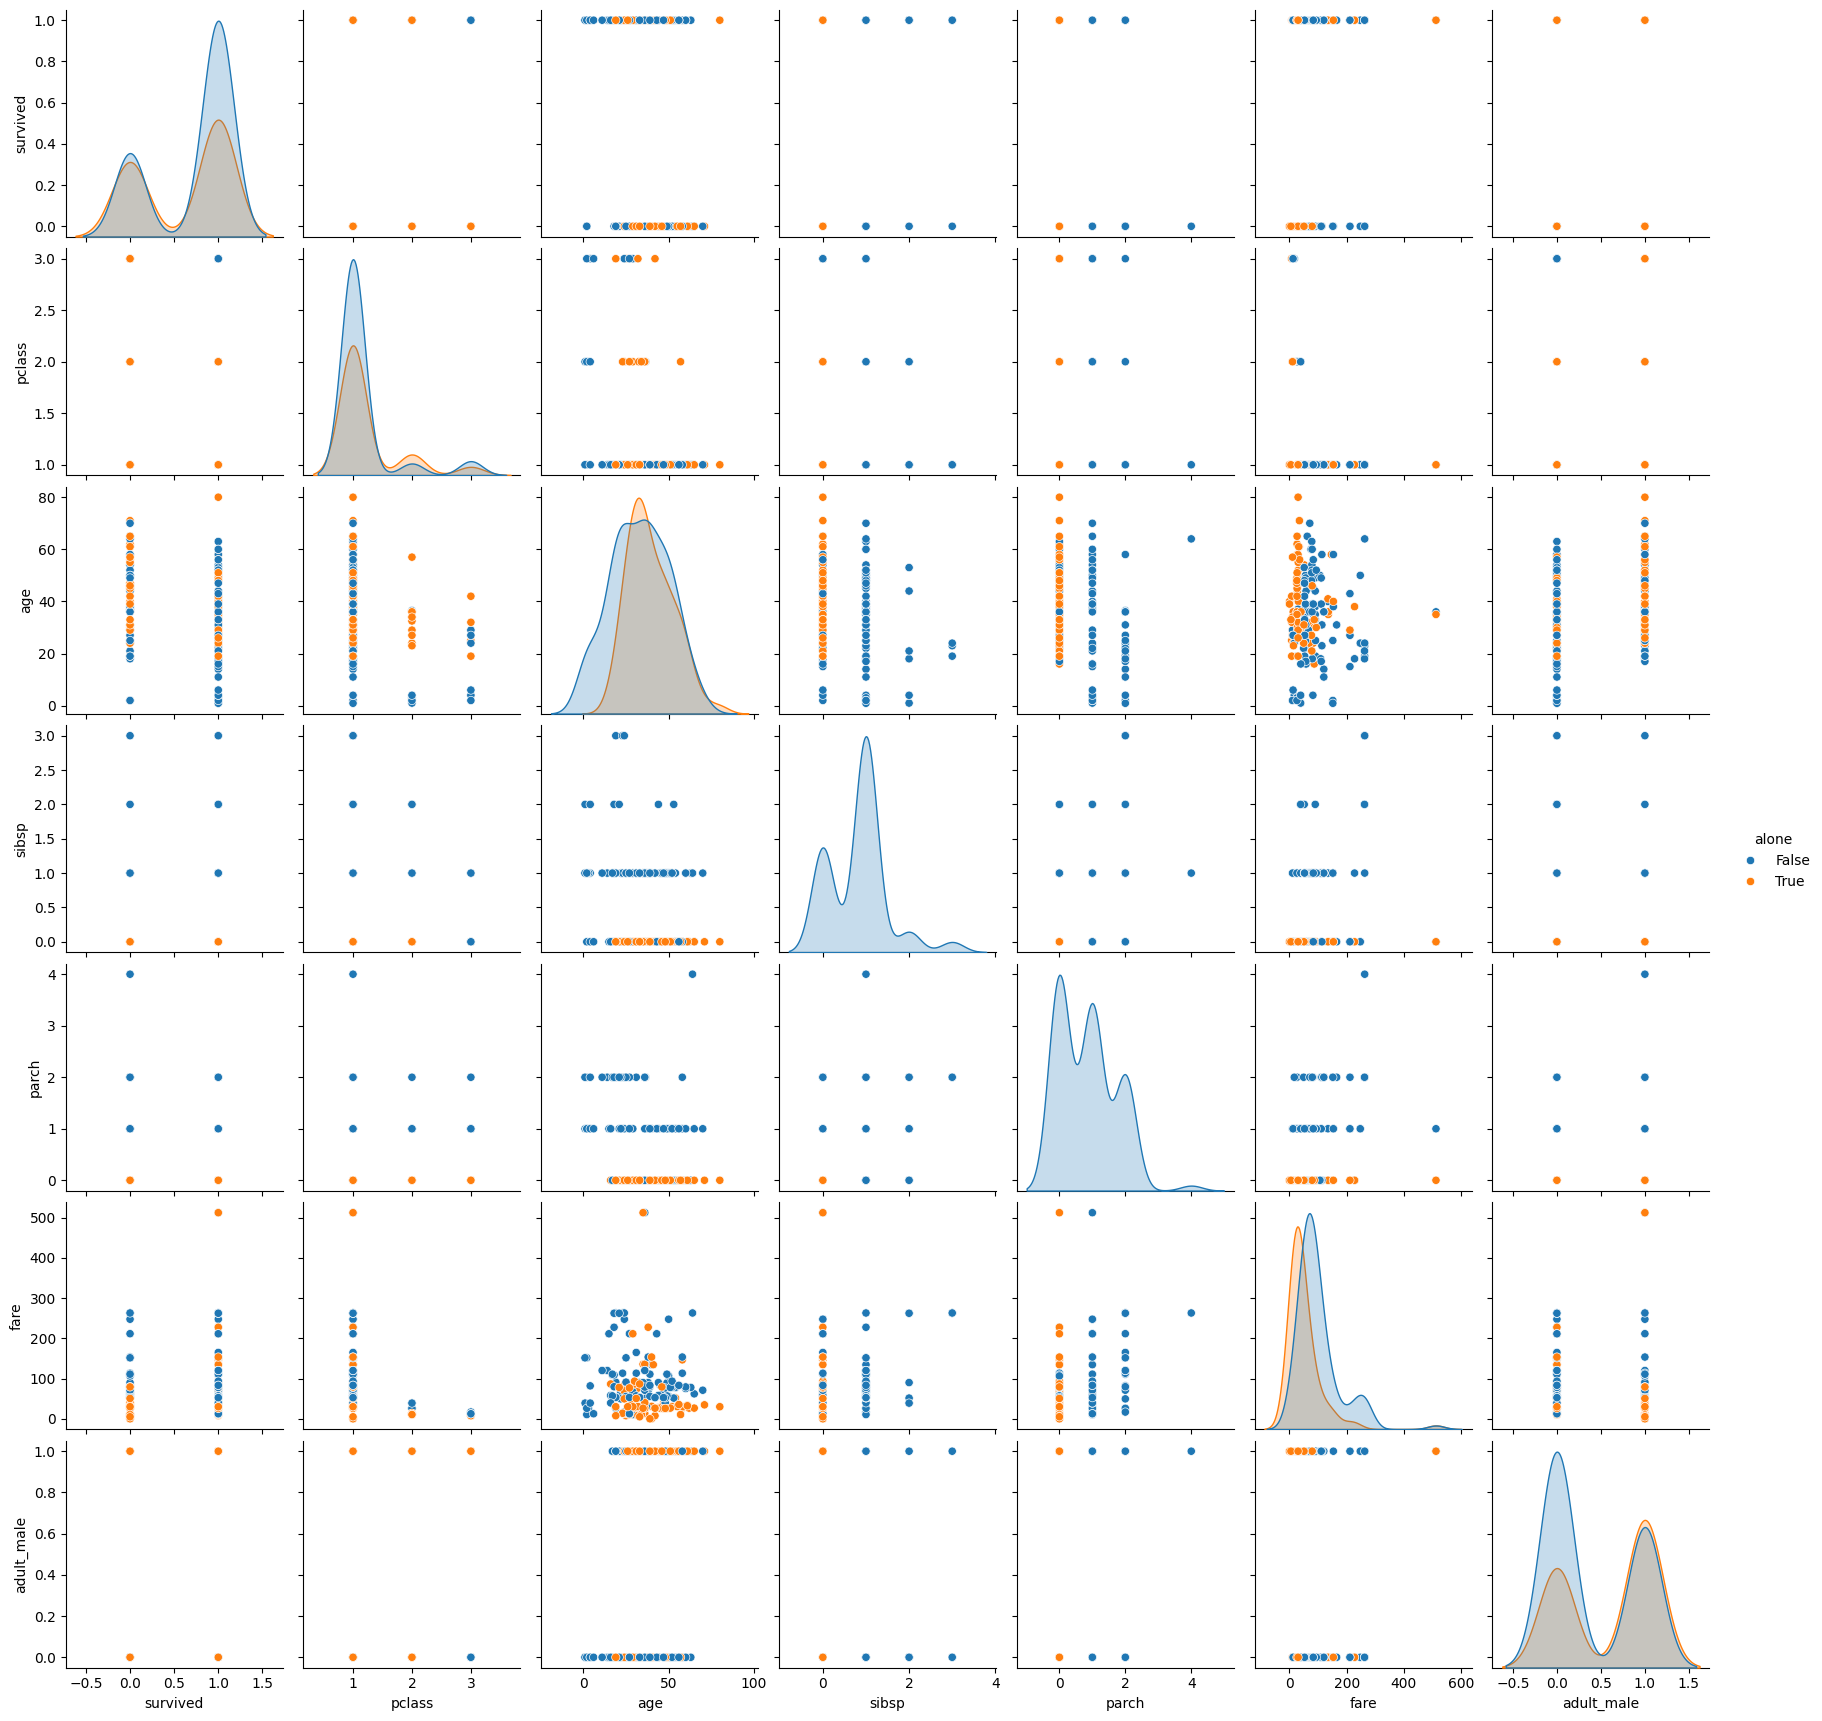

In [84]:
sns.pairplot(df_final, hue='alone')
plt.show()

Find and Remove outliers from the survived column.

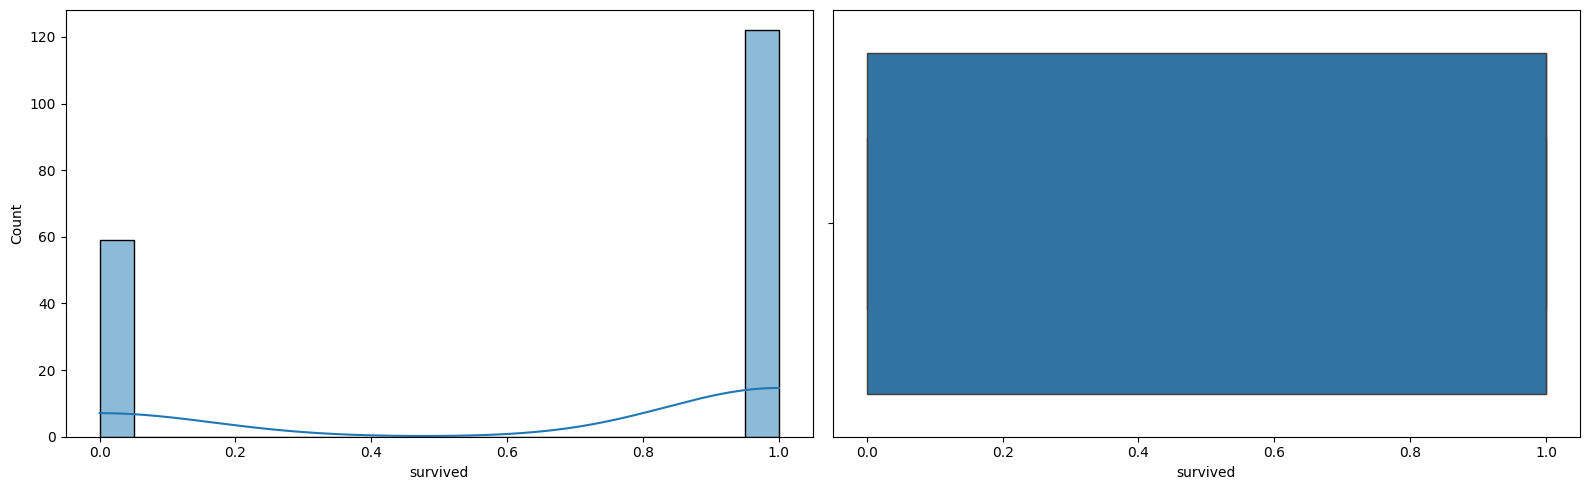

In [85]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["survived"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["survived"])

plt.tight_layout()
plt.show()

Find and Remove outliers from the pclass column.

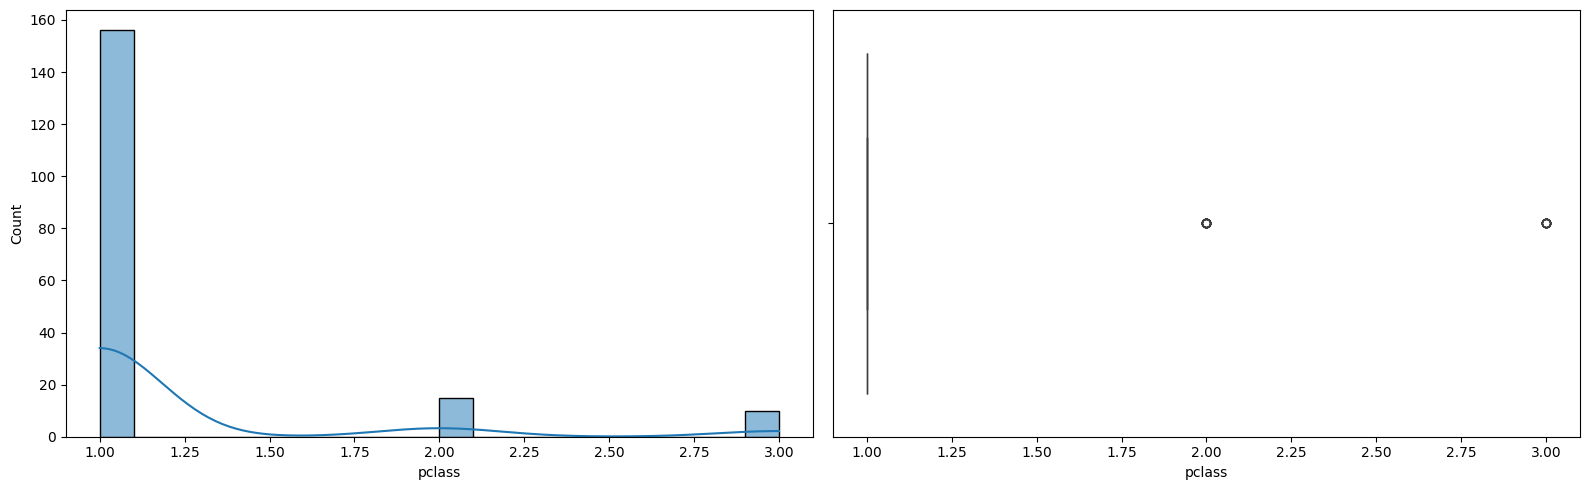

In [86]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["pclass"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["pclass"])

plt.tight_layout()
plt.show()

Find and Remove outliers from age column.

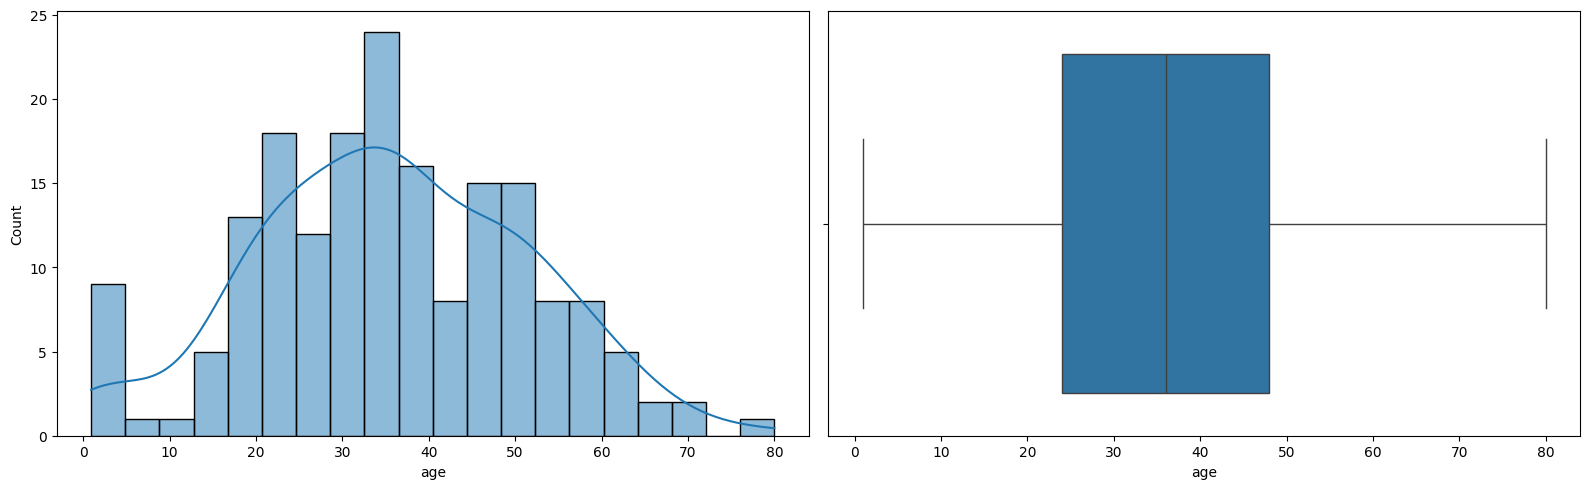

In [87]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["age"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["age"])

plt.tight_layout()
plt.show()

Find and Remove outliers from sibsp column.

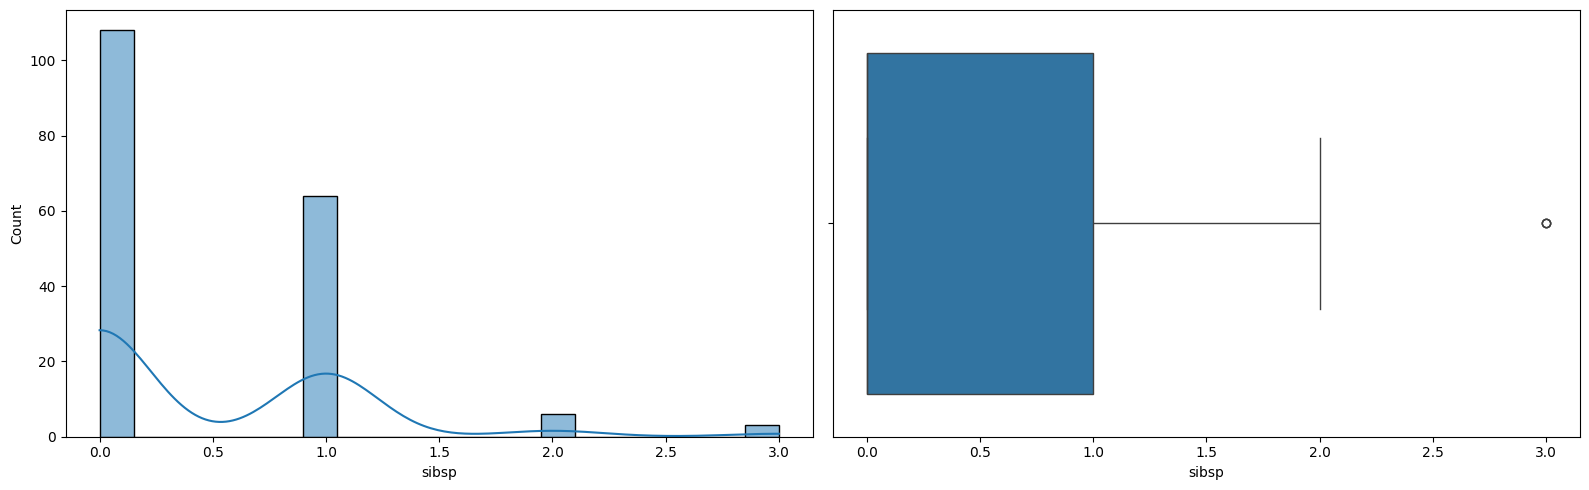

In [88]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["sibsp"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["sibsp"])

plt.tight_layout()
plt.show()

Find and Remove outliers from parch column.

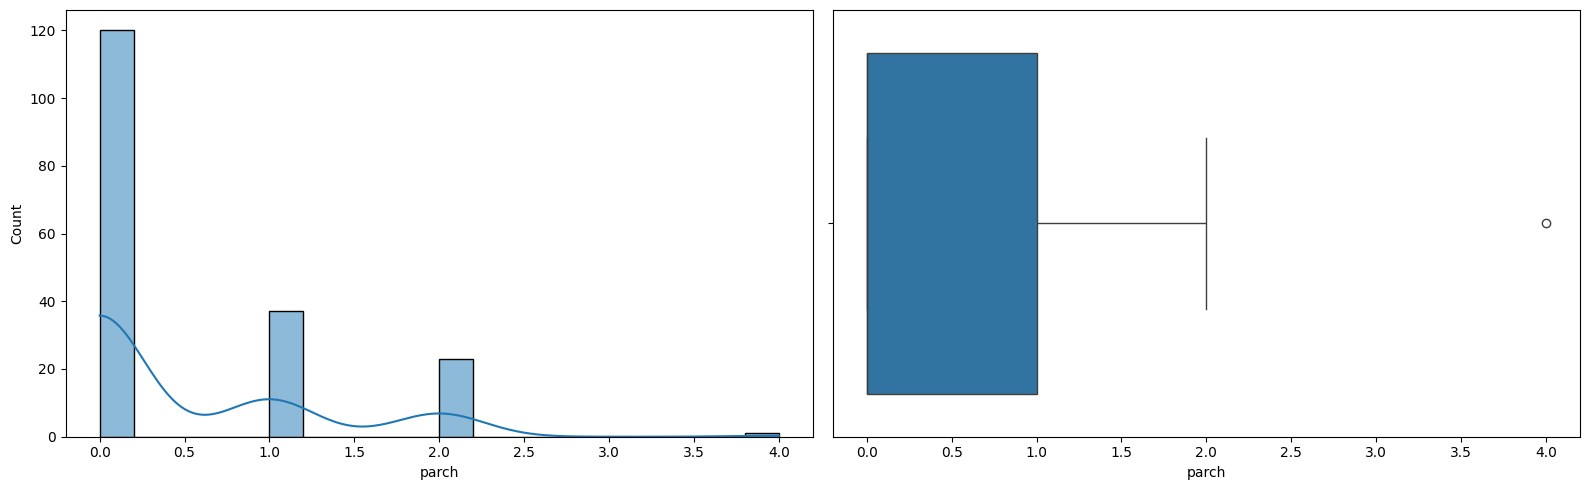

In [89]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["parch"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["parch"])

plt.tight_layout()
plt.show()

Find and Remove outliers from fare column.

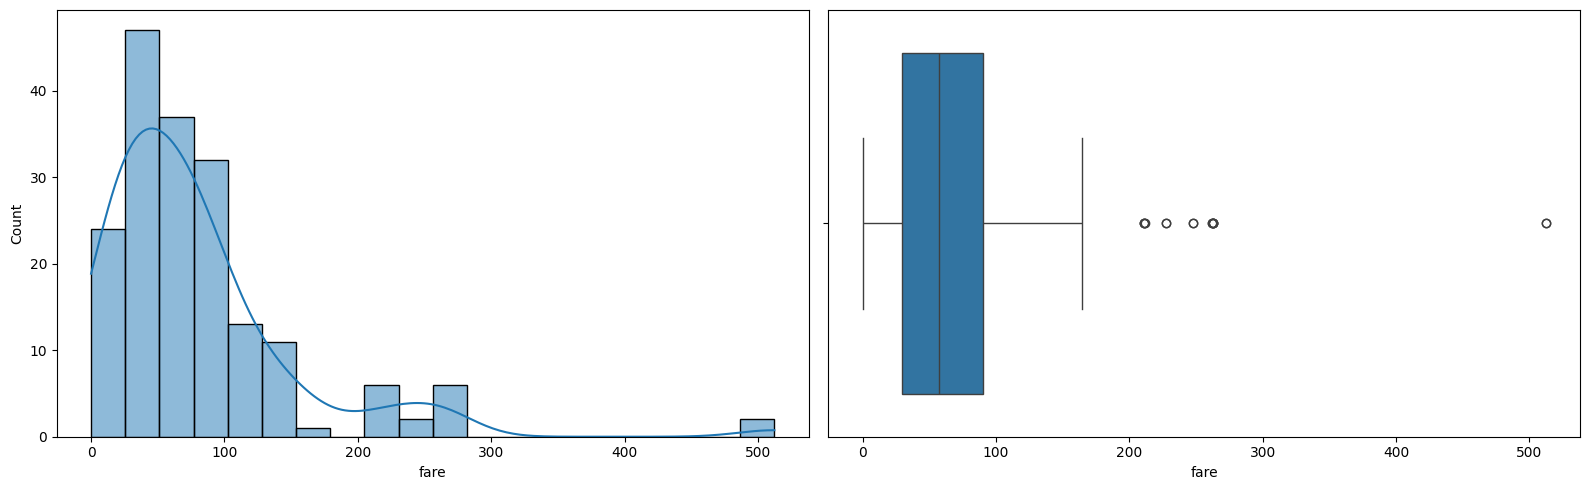

In [90]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["fare"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["fare"])

plt.tight_layout()
plt.show()

In [91]:
# Remove outilers using IQR method
Q1 = df_final["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

print(upper_limit)
print(lower_limit)

32.95
27.75


In [92]:
df_final[df_final["fare"] >= upper_limit]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,deck,alone
1,1,1,female,38.0,1,0,71.2833,C,False,C,False
3,1,1,female,35.0,1,0,53.1000,S,False,C,False
6,0,1,male,54.0,0,0,51.8625,S,True,E,True
23,1,1,male,28.0,0,0,35.5000,S,True,A,True
27,0,1,male,19.0,3,2,263.0000,S,True,C,False
...,...,...,...,...,...,...,...,...,...,...,...
835,1,1,female,39.0,1,1,83.1583,C,False,E,False
853,1,1,female,16.0,0,1,39.4000,S,False,D,False
867,0,1,male,31.0,0,0,50.4958,S,True,A,True
871,1,1,female,47.0,1,1,52.5542,S,False,D,False


In [93]:
df_final[df_final["fare"] <= lower_limit]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,deck,alone
10,1,3,female,4.0,1,1,16.7000,S,False,G,False
11,1,1,female,58.0,0,0,26.5500,S,False,C,True
21,1,2,male,34.0,0,0,13.0000,S,True,D,True
66,1,2,female,29.0,0,0,10.5000,S,False,F,True
75,0,3,male,25.0,0,0,7.6500,S,True,F,True
123,1,2,female,32.5,0,0,13.0000,S,False,E,True
136,1,1,female,19.0,0,2,26.2833,S,False,D,False
148,0,2,male,36.5,0,2,26.0000,S,True,F,False
193,1,2,male,3.0,1,1,26.0000,S,False,F,False
194,1,1,female,44.0,0,0,27.7208,C,False,B,True


In [94]:
df_final["fare"] = np.where(
    df_final["fare"] > upper_limit,
    upper_limit,
    np.where(
        df_final["fare"] < lower_limit,
        lower_limit,
        df_final["fare"]
    )
)

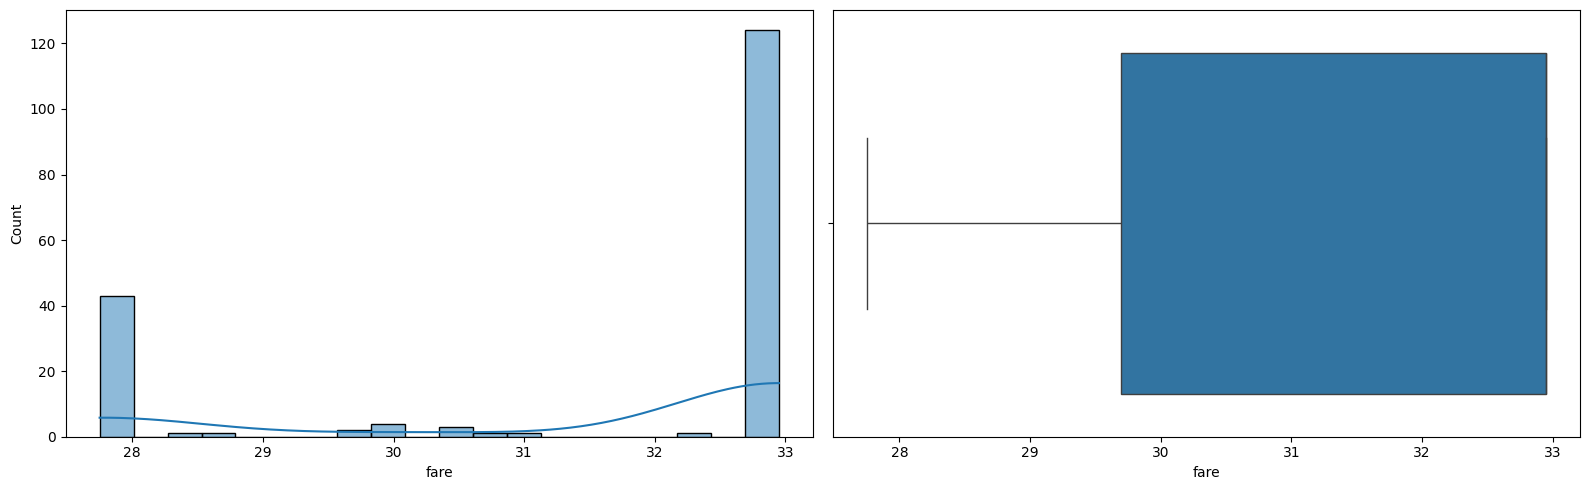

In [95]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["fare"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["fare"])

plt.tight_layout()
plt.show()

Create Dummy variable.

In [96]:
df_final = pd.get_dummies(df_final, columns = ["sex","embarked","deck",], drop_first = True)

In [97]:
df_final

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,embarked_S,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G
1,1,1,38.0,1,0,32.95,False,False,False,False,False,False,True,False,False,False,False
3,1,1,35.0,1,0,32.95,False,False,False,False,True,False,True,False,False,False,False
6,0,1,54.0,0,0,32.95,True,True,True,False,True,False,False,False,True,False,False
10,1,3,4.0,1,1,27.75,False,False,False,False,True,False,False,False,False,False,True
11,1,1,58.0,0,0,27.75,False,True,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,47.0,1,1,32.95,False,False,False,False,True,False,False,True,False,False,False
872,0,1,33.0,0,0,27.75,True,True,True,False,True,True,False,False,False,False,False
879,1,1,56.0,0,1,32.95,False,False,False,False,False,False,True,False,False,False,False
887,1,1,19.0,0,0,30.00,False,True,False,False,True,True,False,False,False,False,False


Create Dependent variable (y) & Independent variable (x),
Distributing data into training and testing.

In [98]:
y = df_final["fare"]
x = df_final.drop("fare", axis = 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

In [99]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [100]:
y_predict = model.predict(x_test)

In [101]:
accuracy = r2_score(y_test, y_predict)
print(f"Final Model Accuracy (R-squared): {accuracy:.2f}")

Final Model Accuracy (R-squared): 0.59


Polynomial Regression...

In [102]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

poly = PolynomialFeatures(degree=2, interaction_only=True)
x_train2 = poly.fit_transform(x_train)
x_test2 = poly.fit_transform(x_test)

poly_clf = linear_model.LinearRegression()

poly_clf.fit(x_train2, y_train)

y_pred = poly_clf.predict(x_test2)


#In sample (training) R^2 will always improve with the number of variables!
print(poly_clf.score(x_train2, y_train))

0.776894693279458


In [103]:
#Out off sample (testing) R^2 is our measure of sucess and does improve
print(poly_clf.score(x_test2, y_test))

-0.5135806895170429


In [104]:
# but this improves as the cost of 29 extra variables!
print(x_train.shape)
print(x_train2.shape)

(144, 16)
(144, 137)


In [106]:
row_number = (int(input("Enter a row number:")))

test_input = x_test.iloc[[row_number]]

original_fare = y_test.iloc[row_number]

predicted_fare = model.predict(test_input)[0]

difference = abs(original_fare - predicted_fare)

print(f"TEST DATA PREDICTION CHECK (Row No: {row_number})")
print(f"Original Price    :  {original_fare:.2f}")
print(f"Predict Price   :  {predicted_fare:.2f}")
print(f"Difference     :  {difference:.2f}")

Enter a row number:5
TEST DATA PREDICTION CHECK (Row No: 5)
Original Price    :  32.95
Predict Price   :  31.24
Difference     :  1.71
